<a href="https://colab.research.google.com/github/lee-doris/HealthCareAnalysis/blob/main/20260807.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Replace with your copied Raw GitHub URL
url = "https://raw.githubusercontent.com/lee-doris/HealthCareAnalysis/refs/heads/main/enhanced_health_insurance_claims.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(url)


In [4]:
# 步驟 1：檢查各欄位的缺失值數量
print("=== 各欄位缺失值數量 ===")
print(df.isnull().sum())


=== 各欄位缺失值數量 ===
ClaimID                    0
PatientID                  0
ProviderID                 0
ClaimAmount                0
ClaimDate                  0
DiagnosisCode              0
ProcedureCode              0
PatientAge                 0
PatientGender              0
ProviderSpecialty          0
ClaimStatus                0
PatientIncome              0
PatientMaritalStatus       0
PatientEmploymentStatus    0
ProviderLocation           0
ClaimType                  0
ClaimSubmissionMethod      0
dtype: int64


In [ ]:
# 步驟 2：選擇處理方式（二選一或依欄位分開處理）

# 做法 A：若缺失值比例極低，直接刪除包含缺失值的列（Rows）
# df_cleaned = df.dropna()

# 做法 B：進行補值（Imputation）
# 數值型欄位（如 PatientAge）：用「中位數」填補（避免極端值影響）
df['PatientAge'] = df['PatientAge'].fillna(df['PatientAge'].median())

# 類別型欄位（如 ClaimStatus）：用「眾數（出現最多次的值）」填補
df['ClaimStatus'] = df['ClaimStatus'].fillna(df['ClaimStatus'].mode()[0])

print("\n補值完成！重新確認缺失值：")
print(df.isnull().sum())

In [5]:
# 步驟 1：計算第一四分位數 (Q1)、第三四分位數 (Q3) 與 IQR
Q1 = df['ClaimAmount'].quantile(0.25)
Q3 = df['ClaimAmount'].quantile(0.75)
IQR = Q3 - Q1

# 步驟 2：定義極端值邊界（通常為 Q3 + 1.5 * IQR）
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"理賠金額正常範圍上限：{upper_bound:.2f}")

# 步驟 3：建立新欄位標記是否為極端值 (True / False)
df['Is_Outlier_Claim'] = (df['ClaimAmount'] > upper_bound) | (df['ClaimAmount'] < lower_bound)

# 步驟 4：查看被標記為極端值的筆數與資料
outlier_count = df['Is_Outlier_Claim'].sum()
print(f"\n共偵測到 {outlier_count} 筆極端理賠金額。")

# 顯示前 5 筆異常高額理賠的紀錄
df[df['Is_Outlier_Claim'] == True][['PatientGender', 'ProviderSpecialty', 'ClaimAmount']].head()

理賠金額正常範圍上限：14892.52

共偵測到 0 筆極端理賠金額。


,PatientGender,ProviderSpecialty,ClaimAmount


In [7]:
#快速看看這些高額理賠主要集中在哪些專科（ProviderSpecialty）
df[df['Is_Outlier_Claim'] == True] ['ProviderSpecialty'].head()

,ProviderSpecialty


In [8]:
# === 1-A. 各專科（ProviderSpecialty）理賠核准率 ===
# 計算各專科在不同 ClaimStatus 的次數與百分比 (Normalize=index 表示依「專科」算橫向比例)
specialty_approval = pd.crosstab(df['ProviderSpecialty'], df['ClaimStatus'], normalize='index') * 100

#pd.crosstab(列, 欄)：建立交叉表（Cross Table / Contingency Table）。
#第一個參數 df['ProviderSpecialty']：放在表格的左側（列 / Rows）。
#第二個參數 df['ClaimStatus']：放在表格的上方（欄 / Columns）。
#如果什麼都不加，它只會統計單純的「次數（Counts）」。

#normalize='index'（關鍵步驟！）：
#normalize 是指將數據「標準化」轉為比例（0 ~ 1 之間的小數）。
#指定 'index' 代表以橫向（列 / Row）為基準算比例。也就是讓每個專科各自的總比例加起來等於 1.0 (100%)。

# * 100：將算出來的小數（例如 0.85）乘以 100，直接轉化成大家習慣看的人類可讀百分比（變成 85，代表 85%）。


# 整理四捨五入顯示百分比 (%)
specialty_approval = specialty_approval.round(2)
#也可以寫成
# specialty_approval =(pd.crosstab(df['ProviderSpecialty'], df['ClaimStatus'], normalize='index') * 100).round(2)

print("=== 各專科理賠核准率 (%) ===")
print(specialty_approval)


# === 1-B. 各性別（PatientGender）理賠核准率 ===
gender_approval = pd.crosstab(df['PatientGender'], df['ClaimStatus'], normalize='index') * 100
gender_approval = gender_approval.round(2)
print("\n=== 各性別理賠核准率 (%) ===")
print(gender_approval)

=== 各專科理賠核准率 (%) ===
ClaimStatus        Approved  Denied  Pending
ProviderSpecialty                           
Cardiology            34.29   34.40    31.31
General Practice      31.82   35.45    32.73
Neurology             35.49   34.22    30.29
Orthopedics           36.39   30.35    33.26
Pediatrics            31.31   33.61    35.08

=== 各性別理賠核准率 (%) ===
ClaimStatus    Approved  Denied  Pending
PatientGender                           
F                 33.83   32.91    33.26
M                 33.81   34.31    31.88


In [9]:
# 依 ProviderSpecialty 分組，計算 ClaimAmount 的 sum (總和), mean (平均), 與 count (筆數)
cost_ranking = df.groupby('ProviderSpecialty')['ClaimAmount'].agg(
    Total_Claim_Amount='sum',
    Average_Claim_Amount='mean',
    Claim_Count='count'
).reset_index()

#df.groupby('ProviderSpecialty')：
#告訴 Pandas 要以 ProviderSpecialty 這個欄位作為分組依據（例如把所有小兒科 Pediatrics 歸為一群、心臟科 Cardiology 歸為一群）。
#['ClaimAmount']：
# 指定我們要針對 ClaimAmount（理賠金額）這個欄位進行數值計算。
# .agg(...)（Aggregate 聚合運算，關鍵靈魂！）：
# .agg() 可以讓我們一次對同一個欄位套用多種統計函數，並且自訂輸出欄位名稱。
# Total_Claim_Amount='sum'：計算該專科所有理賠金額的總和，產出的新欄位叫 Total_Claim_Amount。
# Average_Claim_Amount='mean'：計算該專科理賠金額的平均值，產出的新欄位叫 Average_Claim_Amount。
# Claim_Count='count'：統計該專科共有幾筆理賠申請，產出的新欄位叫 Claim_Count。
# .reset_index()：
# 當我們使用 groupby() 後，原本的分組欄位 ProviderSpecialty 會變成表格的「索引（Index）」。
# 加上 .reset_index() 可以把 ProviderSpecialty 變回一般的資料欄位（Column），讓產出的表格結構呈現乾淨的標準 DataFrame。


# 依「總理賠金額」由高到低排序 (Descending)
cost_ranking = cost_ranking.sort_values(by='Total_Claim_Amount', ascending=False)

# 格式化金額顯示（加入千分位與保留兩位小數，增加可讀性）
cost_ranking_formatted = cost_ranking.copy()
cost_ranking_formatted['Total_Claim_Amount'] = cost_ranking_formatted['Total_Claim_Amount'].map("${:,.2f}".format)
cost_ranking_formatted['Average_Claim_Amount'] = cost_ranking_formatted['Average_Claim_Amount'].map("${:,.2f}".format)

# 1. 為什麼要使用 .copy()？
# ##避免修改到原始數據：
# cost_ranking 裡面存放的是乾淨的數字（Float / Int），方便我們後續繼續做數學運算、繪製圖表或排序。
# 防止 Pandas 的安全警告（SettingWithCopyWarning）：
# 如果不寫 .copy()，直接寫 cost_ranking_formatted = cost_ranking，Pandas 只會建立一個「參照（記憶體指標）」，兩者會連動。當你修改 cost_ranking_formatted 時，原本的 cost_ranking 也會跟著被改成文字，甚至跳出警告訊息。
# ##分工明確：
# cost_ranking ➡️ 保留純數字版（供後續計算/繪圖用）。
# cost_ranking_formatted ➡️ 專門用來做格式美化版（供列印/展示用）。

# 2. 為什麼要使用 .map("${:,.2f}".format)？
# .map() 的作用是將某個格式化規則套用到該欄位的每一個數字上。
# 結構拆解如下：
# .map()：對欄位裡的每一筆資料逐一進行轉換。
# "${:,.2f}"（格式化字串規矩）：
# $：在數字的最前面加上錢號。
# :：代表後面要開始設定格式。
# ,：加上千分位逗號（例如 1000000 變成 1,000,000）。
# .2f：固定保留到小數點後第 2 位（Float），並進行四捨五入。
# .format：Python 的字串填空功能，把原本的數字填入上面設定好的格式中。

# 欄位 資料型態 數據範例
# 轉換前 (cost_ranking)           浮點數 (float64)，適合計算    4521300.5
# 轉換後 (cost_ranking_formatted) 字串(object)，適合展示       $4,521,300.50

print("=== 高成本專科排行榜（依總金額排序）===")
print(cost_ranking_formatted.to_string(index=False))

# 1. 為什麼最後要用 .to_string()？
# 這不是因為 count 還是數值，而是為了控制整張表格在畫面上的「印出樣式」。
# 如果不用 .to_string()（直接 print(cost_ranking_formatted)）：
# Pandas 在印出大型或較寬的 DataFrame 時，為了節省空間，可能會自動省略中間的列/欄（出現 ...），或者為了配合終端機寬度而把表格折行。
# 使用了 .to_string()：
# 它會強制將「整張表格」轉化成一整串完整的純文字格式，確保所有的列與欄都被完整印出來、不被截斷，且對齊非常整齊。


=== 高成本專科排行榜（依總金額排序）===
ProviderSpecialty Total_Claim_Amount Average_Claim_Amount  Claim_Count
       Pediatrics      $4,918,043.88            $5,149.78          955
       Cardiology      $4,549,260.15            $5,015.72          907
      Orthopedics      $4,408,874.73            $4,937.15          893
 General Practice      $4,384,549.77            $4,982.44          880
        Neurology      $4,303,188.87            $4,974.78          865


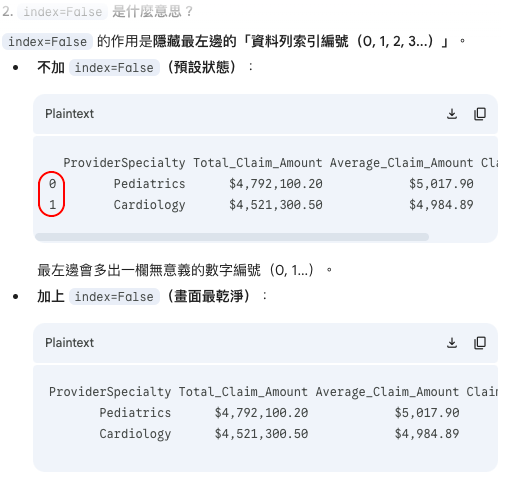

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimID                  4500 non-null   object 
 1   PatientID                4500 non-null   object 
 2   ProviderID               4500 non-null   object 
 3   ClaimAmount              4500 non-null   float64
 4   ClaimDate                4500 non-null   object 
 5   DiagnosisCode            4500 non-null   object 
 6   ProcedureCode            4500 non-null   object 
 7   PatientAge               4500 non-null   int64  
 8   PatientGender            4500 non-null   object 
 9   ProviderSpecialty        4500 non-null   object 
 10  ClaimStatus              4500 non-null   object 
 11  PatientIncome            4500 non-null   float64
 12  PatientMaritalStatus     4500 non-null   object 
 13  PatientEmploymentStatus  4500 non-null   object 
 14  ProviderLocation        